# Free and Forced Eccentricity

This guide shows how the **secular Laplace-Lagrange approach** can be used to understand simple planet-in-binary problems before turning to full numerical simulations.

The main idea is that the planet's eccentricity vector can be separated into two pieces:

1. a **forced eccentricity** set by the binary companion, and
2. a **free eccentricity** set by the planet's initial conditions.

The forced part is the secular equilibrium. The free part is the oscillation around that equilibrium.

The opening oscillator review is kept intentionally because it gives students a familiar mathematical pattern before the guide switches to eccentricity-vector variables.

```{admonition} Purpose of this guide
:class: note

This page is meant to be a working reference, not a full celestial mechanics textbook chapter. The goal is to make the secular model copyable, testable, and useful as a benchmark against more complicated systems.

The examples below are intentionally simple. They are toy problems that help answer practical questions such as:

- What eccentricity should I start with if I want to minimize secular oscillations?
- Why does a circular initial orbit sometimes become eccentric?
- What does it mean for an orbit to be close to the forced eccentricity?
- When is a first-order secular approximation trustworthy?
- When do short-period terms, mean motion resonances, or instability make the secular model unreliable?
```

The notation follows the convention that the planet's longitude of pericenter is compared to the binary's longitude of pericenter through

$$
\Delta\varpi = \varpi_p - \varpi_{\rm bin}.
$$

For most examples below, the binary pericenter is placed along the reference $x$-axis so that $\varpi_{\rm bin}=0$ and $\Delta\varpi=\varpi_p$.


## Why this looks like a forced oscillator

Planets can experience a small but coherent forcing over time, which is referred to as a **secular perturbation**. This type of forcing is reminiscent of perturbations of a harmonic oscillator or pendulum.  

Consider a pendulum (or swing) that oscillates back and forth.  If the perturbation (even if small) is timed when the pendulum reaches its maximum height and along the natural direction of motion, then the overall amplitude of the oscillation will increase over time because the pendulum is receiving a coherent boost along the direction of motion.  

This is in contrast to the pendulum receiving a boost randomly along and against the direction of motion. If the direction and magnitude of the kicks are truly random, then the boost in each direction should cancel out on average resulting in no growth in the oscillation amplitude. 

The components of free and forced eccentricity are described mathematically using concepts of forced and free oscillations of harmonic oscillators that are connected together. This is similar to the problem of a [damped, driven oscillator](http://hyperphysics.phy-astr.gsu.edu/hbase/oscdr.html), which has a linear combination of a steady-state and transient solution. The steady-state solution maps to the forced eccentricity, where the transient solution is the free eccentricity.  The following section reviews the physics of coupled oscillations.

### A Review of Coupled Oscillations

Consider two masses on a *frictionless* plane, where each mass is connected by a spring (with a spring constant $k$) to a wall.  Each spring experiences a force according to Hooke's law (e.g., $F = -kx$).  Additionally, the two springs are connected *to one another* by another spring with a spring constant $\kappa$.

```{figure-md} coupled_masses
<img src="coupled_masses.png" alt="coupled masses"  width="400px">

Two identical masses attached to their respective wall with a spring with a spring constant $k$.  The masses are coupled by another spring (with a spring constant $\kappa$) and slide on a frictionless plane.
```

The mass on the left is displaced by a distance $x_1$ to the right.  It's left spring will apply a force to bring it back to the equilibrium, but the middle spring will compress along with the rightmost spring.  The compression of the middle and right spring will apply a force on the other mass on the right.  Because the masses are connected, there will be a similar set of forces acting on the mass on the right.  Altogether the forces on the left and right mass are:

\begin{align}
\mathbf{F}_{\rm left} &= -kx_1 + \kappa(x_2-x_1) = m\ddot{x}_1, \\
\mathbf{F}_{\rm right} &= -kx_2 + \kappa(x_1-x_2) = m\ddot{x}_2.
\end{align}

Notice that each of these equations have a part that we expect from an isolated spring and a part that describes the interaction via the connecting spring with spring constant $\kappa$.  Furthermore, the interaction on the left mass is equal and opposite to the interaction force on the right mass.  The above equations can be rearranged to get:

\begin{align}
 m \ddot{x}_1 &= -(\kappa + k)x_1 + \kappa x_2, \\
 m \ddot{x}_2 &= \kappa x_1 - (\kappa + k)x_2,
\end{align}

or in matrix form as:

\begin{align}
\begin{pmatrix} 
m\ddot{x}_1 \\ m\ddot{x}_2 
\end{pmatrix} &= 
\begin{bmatrix} 
-(\kappa + k) & \kappa \\ \kappa & -(\kappa + k) 
\end{bmatrix} 
\begin{pmatrix}
x_1 \\ x_2 
\end{pmatrix}.
\end{align}

Let's use the following trial functions:

\begin{align}
x_1(t) &= B_1 e^{i\omega t}, \\
x_2(t) &= B_2 e^{i\omega t},
\end{align}

based on our prior knowledge concerning the isolated springs.  Upon substitution, we get

\begin{align}
-m\omega^2\begin{pmatrix} 
B_1 e^{i\omega t} \\ B_2 e^{i\omega t}
\end{pmatrix} &= 
\begin{bmatrix} 
-(\kappa + k) & \kappa \\ \kappa & -(\kappa + k) 
\end{bmatrix} 
\begin{pmatrix}
B_1 e^{i\omega t} \\ B_2 e^{i\omega t} 
\end{pmatrix},
\end{align}

or

\begin{align}
\begin{bmatrix} 
(\kappa + k) - m\omega^2 & -\kappa \\ -\kappa & (\kappa + k) - m\omega^2
\end{bmatrix} 
\begin{pmatrix}
B_1 e^{i\omega t} \\ B_2 e^{i\omega t} 
\end{pmatrix} &=
\begin{pmatrix}
0 \\ 0
\end{pmatrix}.
\end{align}

The trivial solution is $B_1 = B_2 = 0$.  But the non-trivial solution is solved via the characteristic equation (or determinant) via:

\begin{align}
\left[(\kappa + k) - m\omega^2\right]^2 - \kappa^2 &= 0, \\
(m\omega^2)^2 - 2m(\kappa + k)\omega^2 + (\kappa + k)^2 - \kappa^2 &= 0, \\
x^2 -2(\kappa+k)x + 2\kappa k + k^2 & = 0,
\end{align}

which has solutions via the quadratic equation:

\begin{align}
x &= (\kappa + k) \pm \frac{1}{2}\sqrt{4(\kappa + k)^2 - 4(2\kappa k + k^2)}, \\
m\omega^2 &= (\kappa + k) \pm \kappa, \\
\omega &= \pm \sqrt{\frac{(\kappa + k) \pm \kappa}{m}}.
\end{align}

Each root (from the quadratic equation) permits a separate eigenfrequency:

\begin{align}
\omega_1 = \pm \sqrt{\frac{2\kappa + k}{m}}, \qquad& \text{and} \qquad&
\omega_2 = \pm \sqrt{\frac{k}{m}}.
\end{align}

To determine the coefficients $B_1$ and $B_2$, we substitute the eigenfrequencies ($\omega_1$ and $\omega_2$) back into the characteristic equation to get:

\begin{align}
\left[ k + \kappa - (k + 2\kappa) \right]B_1 - \kappa B_2 &= -\kappa (B_1 + B_2) = 0,&\ (\text{for } \omega_1;\  B_1 = -B_2) \\
\left( k+ \kappa - k\right)B_1 - \kappa B_2 &= \kappa (B_1 - B_2) = 0.&  (\text{for } \omega_2;\  B_1 = B_2)
\end{align}

The most general solution of the coupled harmonic oscillator problem is

\begin{align}
x_1(t) &= B_1^+ e^{+i\omega_1 t} + B_1^- e^{-i\omega_1 t} + B_2^+ e^{+i\omega_2 t} + B_2^- e^{-i\omega_2 t}, \\
x_2(t) &= -B_1^+ e^{+i\omega_1 t} - B_1^- e^{-i\omega_1 t} + B_2^+ e^{+i\omega_2 t} + B_2^- e^{-i\omega_2 t}.
\end{align}

Depending on initial and boundary conditions, Euler's equation could be used to transform the above into a linear combination of $\sin$ and $\cos$ functions.  For more details, see the [lecture](https://scholar.harvard.edu/files/schwartz/files/lecture3-coupled-oscillators.pdf) by Matthew Schwartz at Harvard or [libretexts](https://phys.libretexts.org/Courses/University_of_California_Davis/UCD%3A_Physics_9HA__Classical_Mechanics/8%3A_Small_Oscillations/8.4%3A_Coupled_Oscillators_and_Normal_Modes) by Tom Weideman at UC Davis, or lectures on YouTube from Jeffery Chasnov (see below).  There is also a guide for the generalized method from [Lagrangian dynamics](http://teacher.pas.rochester.edu/PHY235/LectureNotes/Chapter12/Chapter12.pdf) provided by the University of Rochester that may be helpful.


<div align="center">

<iframe width="560" height="315"
src="https://www.youtube.com/embed/-pXnfzQfupE"
frameborder="0" 
allow="accelerometer; autoplay; encrypted-media; gyroscope; picture-in-picture" 
allowfullscreen></iframe>

</div>

<div align="center">

<iframe width="560" height="315"
src="https://www.youtube.com/embed/cU4b1vI-J2k"
frameborder="0" 
allow="accelerometer; autoplay; encrypted-media; gyroscope; picture-in-picture" 
allowfullscreen></iframe>

</div>

<div align="center">

<iframe width="560" height="315"
src="https://www.youtube.com/embed/xtFUMtHjzAE"
frameborder="0" 
allow="accelerometer; autoplay; encrypted-media; gyroscope; picture-in-picture" 
allowfullscreen></iframe>

</div>





## From Coupled Oscillators to Eccentricity Vectors

The coupled-oscillator example is not just a mechanics review. It gives us the mathematical pattern we need for secular eccentricity evolution.

In the spring problem, the motion is described by a sum of normal modes. The motion of each mass can be written as a combination of oscillatory pieces whose amplitudes are set by the initial conditions. The important point is that a complicated-looking interaction becomes easier to understand after we choose better variables.

In the secular eccentricity problem, the same idea appears in a different coordinate system. Instead of tracking a displacement $x(t)$, we track the eccentricity-vector components

\begin{align*}
k &= e_p\cos\Delta\varpi,\\
h &= e_p\sin\Delta\varpi.
\end{align*}

The forced eccentricity plays the role of a displaced equilibrium point. The free eccentricity plays the role of the oscillation amplitude around that displaced point. In the simplest S-Type secular model, the solution has the form

\begin{align*}
k(t) &= e_{\rm free}\cos(gt+\phi) + e_{\rm forced},\\
h(t) &= e_{\rm free}\sin(gt+\phi).
\end{align*}

This means that the eccentricity vector moves in a circle in the $(k,h)$ plane. The center of that circle is the forced eccentricity, and the radius of that circle is the free eccentricity.

```{admonition} Key idea
:class: note

The forced eccentricity is not the maximum eccentricity. It is the center of the secular oscillation in eccentricity-vector space. The free eccentricity is the distance from the current eccentricity vector to that forced point.
```

This is the bridge from the oscillator analogy to the secular Laplace-Lagrange model. The rest of the guide uses this idea as a benchmark: first understand the simple eccentricity-vector oscillator, then compare it with more complete numerical or higher-order treatments.


## Eccentricity as a vector

For secular theory, it is often better to use the eccentricity vector components instead of eccentricity and longitude of pericenter separately. We define

\begin{align*}
k &= e_p\cos\Delta\varpi,\\
h &= e_p\sin\Delta\varpi.
\end{align*}

The ordinary eccentricity is the distance from the origin in the $(k,h)$ plane:

$$
e_p = \sqrt{k^2+h^2}.
$$

The angle in the $(k,h)$ plane is the relative longitude of pericenter:

$$
\Delta\varpi = \tan^{-1}\left(\frac{h}{k}\right).
$$

In code, always use `np.arctan2(h, k)` instead of `np.arctan(h/k)` so the angle is placed in the correct quadrant.

```{admonition} Why use $k$ and $h$?
:class: note

The variables $e_p$ and $\Delta\varpi$ become awkward when $e_p \to 0$ because the pericenter direction is undefined for a circular orbit. The variables $k$ and $h$ remain well behaved.
```


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Use astronomical units, solar masses, and years.
# With this choice, G = 4*pi^2.
G = 4 * np.pi**2

plt.rcParams.update({
    "font.size": 13,
    "mathtext.fontset": "cm",
    "figure.dpi": 120
})

def eccentricity_vector(e, delta_varpi):
    """Return the eccentricity-vector components k and h."""
    k = e * np.cos(delta_varpi)
    h = e * np.sin(delta_varpi)
    return k, h

def eccentricity_from_vector(k, h):
    """Return eccentricity and angle from eccentricity-vector components."""
    e = np.sqrt(k**2 + h**2)
    delta_varpi = np.arctan2(h, k)
    return e, delta_varpi

## S-Type architecture

An **S-Type planet** orbits one star in a binary system. The companion star acts as an external perturber. The basic hierarchy is shown in {numref}`fig-s-type-architecture`.

```{figure} S_type_fig.png
:name: fig-s-type-architecture
:width: 100%
:align: center

S-Type hierarchical architecture. The planet $m_2$ orbits the host star $m_1$, while the stellar companion $m_3$ orbits the center of mass of the inner pair. The blue point marks the center of mass used in the hierarchical coordinate system.
```

This figure uses the same coordinate logic introduced in the [Introduction to the $\alpha$ Centauri System](https://saturnaxis.github.io/exoplanet-binary/Tutorials/intro-alpha-centauri.html#). The semimajor axes are defined relative to the appropriate center of mass. In the S-Type hierarchy, $a_1$ and $a_2$ describe the motion of the host star and planet around their inner center of mass, while $a_3$ describes the stellar companion relative to that same center of mass. 

Because the planet is much less massive than either star, $m_2 \ll m_1$ and the host star barely moves around the inner center of mass. Therefore, the planet semimajor axis used in the simplified secular model is approximately

$$
a_p = a_1 + a_2 \approx a_2.
$$

The binary semimajor axis is the outer separation scale, so in this notation

$$
a_{\rm bin} = a_3.
$$

We will use the following simplified notation:

| Symbol | Meaning |
|---|---|
| $m_1$ | planet-hosting star |
| $m_2$ | planet |
| $m_3$ | stellar companion |
| $a_p$ | planet semimajor axis around the host star, approximately $a_2$ in the figure |
| $a_{\rm bin}$ | binary semimajor axis, equal to $a_3$ in the figure |
| $e_{\rm bin}$ | binary eccentricity |
| $\alpha$ | semimajor axis ratio, $\alpha = a_p/a_{\rm bin}$ |
| $\mu$ | perturber mass ratio, $\mu = m_3/(m_1+m_2)$ |
| $n_p$ | planet mean motion |

For a hierarchical S-Type planet, $\alpha \ll 1$. The secular model assumes that the planet is not too close to the companion star and not strongly affected by mean motion resonances.

## The Heppenheimer S-Type model

The first benchmark model is the low-eccentricity secular model associated with Heppenheimer. It comes from expanding the disturbing function in powers of $\alpha = a_p/a_{\rm bin}$ and keeping the leading terms that affect the planet's eccentricity vector.

In this approximation, the semimajor axis is nearly constant:

$$
\dot{a}_p \approx 0.
$$

The long-term dynamics are carried by $k$ and $h$. The equations of motion are

\begin{align*}
\dot{k} &= -g_H h,\\
\dot{h} &= g_H(k-\epsilon_H).
\end{align*}

The two important constants are

\begin{align*}
g_H &= \frac{3}{4}\mu\alpha^3\frac{n_p}{(1-e_{\rm bin}^2)^{3/2}},\\
\epsilon_H &= \frac{5}{4}\alpha\frac{e_{\rm bin}}{1-e_{\rm bin}^2}.
\end{align*}

Here $g_H$ is the secular precession frequency and $\epsilon_H$ is the forced eccentricity.

```{admonition} Physical meaning
:class: note

The forced eccentricity $\epsilon_H$ is the stationary solution. If the planet starts at $k=\epsilon_H$ and $h=0$, then the first-order secular model predicts no free eccentricity oscillation.
```


In [ ]:
def mean_motion(a, mass, G=G):
    """Return mean motion in radians per year for a semimajor axis in AU and mass in solar masses."""
    return np.sqrt(G * mass / a**3)

def heppenheimer_s_type(m_host, m_planet, m_companion, a_p, a_bin, e_bin, G=G):
    """Return the Heppenheimer secular frequency and forced eccentricity for an S-Type planet."""
    alpha = a_p / a_bin
    mu = m_companion / (m_host + m_planet)
    n_p = mean_motion(a_p, m_host + m_planet, G=G)
    g_H = 0.75 * mu * alpha**3 * n_p / (1 - e_bin**2)**1.5
    eps_H = 1.25 * alpha * e_bin / (1 - e_bin**2)
    return g_H, eps_H

def marchal_s_type(m_host, m_planet, m_companion, a_p, a_bin, e_bin, G=G):
    """Return a Marchal-style corrected secular frequency and forced eccentricity.

    This correction follows the compact form used in the binary-stability chapter:
    g_M = g_H(1 + delta_M), eps_M = eps_H/(1 + delta_M).
    """
    g_H, eps_H = heppenheimer_s_type(m_host, m_planet, m_companion, a_p, a_bin, e_bin, G=G)
    alpha = a_p / a_bin
    mu = m_companion / (m_host + m_planet)
    delta_M = (25/8) * mu * alpha**1.5 * (3 + 2*e_bin**2) / (np.sqrt(1 + mu) * (1 - e_bin**2)**1.5)
    g_M = g_H * (1 + delta_M)
    eps_M = eps_H / (1 + delta_M)
    return g_M, eps_M, delta_M

def secular_solution(t, g, e_forced, e0, delta_varpi0=0.0):
    """Return k, h, e, and delta_varpi for the secular eccentricity-vector solution."""
    k0, h0 = eccentricity_vector(e0, delta_varpi0)
    e_free = np.sqrt((k0 - e_forced)**2 + h0**2)
    phase = np.arctan2(h0, k0 - e_forced)

    k = e_free * np.cos(g * t + phase) + e_forced
    h = e_free * np.sin(g * t + phase)
    e, delta_varpi = eccentricity_from_vector(k, h)
    return k, h, e, delta_varpi, e_free, phase

### Example: three initial eccentricities

The example below reproduces the basic behavior of the Heppenheimer solution. The forced eccentricity does not depend on the planet's initial eccentricity. The initial eccentricity only changes the size of the free oscillation around the forced point.

The chosen toy system has

\begin{align*}
m_1 &= 1\ M_\odot,\\
m_3 &= 1\ M_\odot,\\
a_p &= 0.1\ {\rm AU},\\
a_{\rm bin} &= 1.0\ {\rm AU},\\
e_{\rm bin} &= 0.3.
\end{align*}

This gives $\alpha=0.1$, so the planet is well inside the binary separation and the first-order secular model is at least a reasonable benchmark.


In [ ]:
# Toy S-Type system.
m_host = 1.0
m_planet = 0.0
m_companion = 1.0
a_p = 0.1
a_bin = 1.0
e_bin = 0.3

g_H, eps_H = heppenheimer_s_type(m_host, m_planet, m_companion, a_p, a_bin, e_bin)
period_sec = 2 * np.pi / g_H

print(f"The Heppenheimer forced eccentricity is eps_H = {eps_H:.4f}.")
print(f"The secular frequency is g_H = {g_H:.4f} rad/yr.")
print(f"The secular period is 2*pi/g_H = {period_sec:.2f} yr.")

The Heppenheimer forced eccentricity is eps_H = 0.0412.
The secular frequency is g_H = 0.1717 rad/yr.
The secular period is 2*pi/g_H = 36.60 yr.


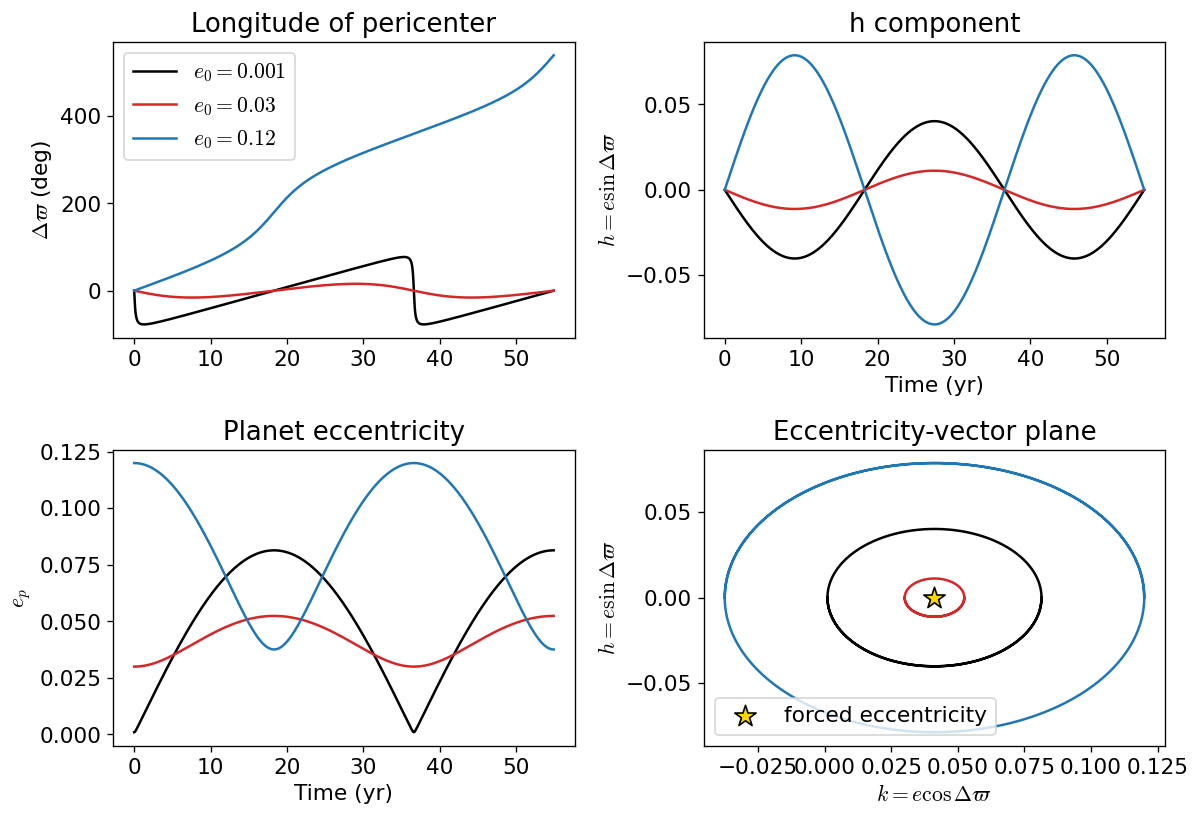

In [ ]:
# Evolve several different initial eccentricities.
t = np.linspace(0, 1.5 * period_sec, 1000)
initial_eccentricities = [0.001, 0.03, 0.12]
colors = ["black", "tab:red", "tab:blue"]

fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=False)

for e0, color in zip(initial_eccentricities, colors):
    k, h, e, dvarpi, e_free, phase = secular_solution(t, g_H, eps_H, e0, delta_varpi0=0.0)
    axes[0, 0].plot(t, np.degrees(np.unwrap(dvarpi)), color=color, label=rf"$e_0={e0}$")
    axes[1, 0].plot(t, e, color=color)
    axes[0, 1].plot(t, h, color=color)
    axes[1, 1].plot(k, h, color=color)

axes[1, 1].scatter([eps_H], [0], marker="*", s=180, color="gold", edgecolor="black", zorder=5, label="forced eccentricity")
axes[0, 0].set_ylabel(r"$\Delta\varpi$ (deg)")
axes[1, 0].set_ylabel(r"$e_p$")
axes[0, 1].set_ylabel(r"$h=e\sin\Delta\varpi$")
axes[1, 1].set_ylabel(r"$h=e\sin\Delta\varpi$")
axes[1, 0].set_xlabel("Time (yr)")
axes[0, 1].set_xlabel("Time (yr)")
axes[1, 1].set_xlabel(r"$k=e\cos\Delta\varpi$")
axes[0, 0].legend(loc="best")
axes[1, 1].legend(loc="best")
axes[0, 0].set_title("Longitude of pericenter")
axes[1, 0].set_title("Planet eccentricity")
axes[0, 1].set_title("h component")
axes[1, 1].set_title("Eccentricity-vector plane")

plt.tight_layout()
plt.show()

## Free eccentricity and maximum eccentricity

The secular solution can be written as

\begin{align*}
k(t) &= e_{\rm free}\cos(g_H t+\phi) + \epsilon_H,\\
h(t) &= e_{\rm free}\sin(g_H t+\phi).
\end{align*}

The free eccentricity is determined by the initial eccentricity vector:

$$
e_{\rm free} = \sqrt{[k(0)-\epsilon_H]^2 + h(0)^2}.
$$

The phase is

$$
\phi = \tan^{-1}\left(\frac{h(0)}{k(0)-\epsilon_H}\right),
$$

where the `arctan2` form should be used in code.

The maximum and minimum eccentricities in the secular cycle are approximately

\begin{align*}
e_{\max} &= \epsilon_H + e_{\rm free},\\
e_{\min} &= \left|\epsilon_H - e_{\rm free}\right|.
\end{align*}

```{admonition} Practical consequence
:class: tip

If you start the planet on a circular orbit, the planet is not necessarily dynamically "cold." A circular initial condition has $e_{\rm free}=\epsilon_H$, so the eccentricity can oscillate up to about $2\epsilon_H$.
```


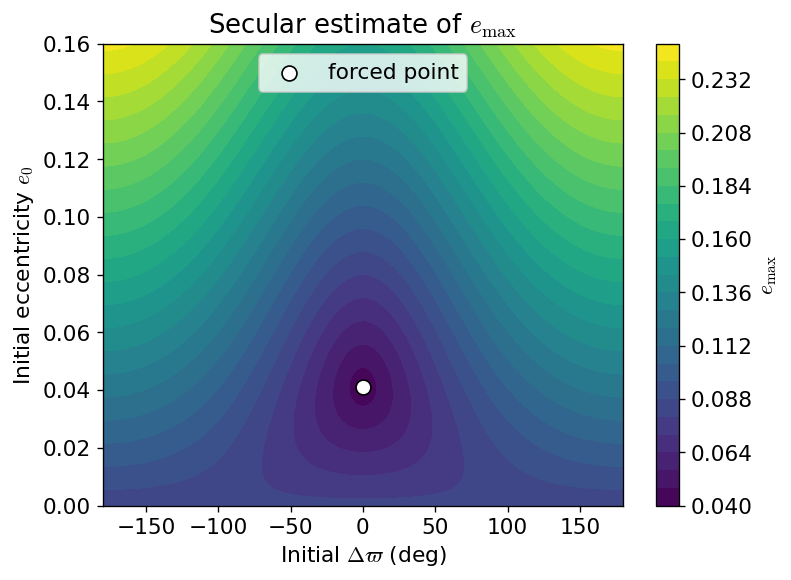

In [ ]:
def free_eccentricity(e0, delta_varpi0, e_forced, varpi_forced=0.0):
    """Return free eccentricity relative to a forced eccentricity vector."""
    k0 = e0 * np.cos(delta_varpi0)
    h0 = e0 * np.sin(delta_varpi0)
    kF = e_forced * np.cos(varpi_forced)
    hF = e_forced * np.sin(varpi_forced)
    return np.sqrt((k0 - kF)**2 + (h0 - hF)**2)

def max_eccentricity(e0, delta_varpi0, e_forced, varpi_forced=0.0):
    """Return approximate secular maximum eccentricity."""
    e_free = free_eccentricity(e0, delta_varpi0, e_forced, varpi_forced=varpi_forced)
    return e_forced + e_free

# Show how initial eccentricity and pericenter alignment change e_max.
e0_grid = np.linspace(0, 0.16, 150)
dvarpi_grid = np.radians(np.linspace(-180, 180, 241))
DVARPI, E0 = np.meshgrid(dvarpi_grid, e0_grid)
EMAX = max_eccentricity(E0, DVARPI, eps_H)

fig, ax = plt.subplots(figsize=(7, 5))
cs = ax.contourf(np.degrees(DVARPI), E0, EMAX, levels=25)
ax.scatter([0], [eps_H], color="white", edgecolor="black", s=80, zorder=4, label="forced point")
ax.set_xlabel(r"Initial $\Delta\varpi$ (deg)")
ax.set_ylabel(r"Initial eccentricity $e_0$")
ax.set_title(r"Secular estimate of $e_{\max}$")
fig.colorbar(cs, ax=ax, label=r"$e_{\max}$")
ax.legend(loc="upper center")
plt.show()

The dark minimum in the map occurs near $e_0=\epsilon_H$ and $\Delta\varpi=0$. That is the initial condition closest to the forced eccentricity vector.

For an S-Type planet, the forced vector usually points in the direction of the binary pericenter in this simple model. Starting aligned with the binary and near the forced eccentricity minimizes the free eccentricity.


## First-order, Marchal, and empirical corrections

The Heppenheimer model is useful because it is simple. It is also limited. It assumes a hierarchical system and low planetary eccentricity. As the planet moves closer to the binary companion, higher-order terms and short-period effects become more important.

A commonly used compact correction has the form

\begin{align*}
g_M &= g_H(1+\delta_M),\\
\epsilon_M &= \epsilon_H(1+\delta_M)^{-1},
\end{align*}

where

$$
\delta_M =
\frac{25}{8}
\frac{\mu \alpha^{3/2}}{\sqrt{1+\mu}}
\frac{3+2e_{\rm bin}^2}{(1-e_{\rm bin}^2)^{3/2}}.
$$

This correction shifts the secular frequency and forced eccentricity while keeping the same geometric picture: the eccentricity vector still circulates around a forced point.

```{admonition} How to use this correction
:class: note

Use the Heppenheimer model first because it is transparent. Then use the corrected model as a quick check of whether first-order terms are already becoming inaccurate. If the correction is large, do not overinterpret the first-order secular model.
```


In [ ]:
g_M, eps_M, delta_M = marchal_s_type(m_host, m_planet, m_companion, a_p, a_bin, e_bin)

print(f"For this toy system, delta_M = {delta_M:.4f}.")
print(f"Heppenheimer: g_H = {g_H:.4f} rad/yr, eps_H = {eps_H:.4f}.")
print(f"Marchal-style corrected: g_M = {g_M:.4f} rad/yr, eps_M = {eps_M:.4f}.")
print(f"The corrected secular period is {2*np.pi/g_M:.2f} yr.")

For this toy system, delta_M = 0.2560.
Heppenheimer: g_H = 0.1717 rad/yr, eps_H = 0.0412.
Marchal-style corrected: g_M = 0.2156 rad/yr, eps_M = 0.0328.
The corrected secular period is 29.14 yr.


### Andrade-Ines style empirical correction

The binary-stability chapter describes a more flexible empirical correction that can be represented as finite sums:

\begin{align*}
\delta_g &= \sum_{i=1}^{N_g} A_i^g \alpha^{p_i^g}\mu^{q_i^g}e_{\rm bin}^{\ell_i^g},\\
\delta_e &= \sum_{i=1}^{N_e} A_i^e \alpha^{p_i^e}\mu^{q_i^e}e_{\rm bin}^{\ell_i^e}.
\end{align*}

Then

\begin{align*}
g_{\rm AI} &= g_H(1+\delta_g),\\
\epsilon_{\rm AI} &= \epsilon_H(1+\delta_e).
\end{align*}

This is the same idea as the compact correction above, but with coefficients fitted to a broader set of numerical experiments.

The code below is a reusable pattern for applying any coefficient table of this form. The table must contain columns for the amplitude and exponents.


In [ ]:
def finite_sum_correction(alpha, mu, e_bin, coeffs):
    """Evaluate a finite-sum correction.

    Parameters
    ----------
    alpha : float
        Semimajor axis ratio.
    mu : float
        Perturber mass ratio.
    e_bin : float
        Binary eccentricity.
    coeffs : list of tuples
        Each tuple should contain (A, p, q, ell).

    Returns
    -------
    correction : float
        The value of sum A * alpha**p * mu**q * e_bin**ell.
    """
    correction = 0.0
    for A, p, q, ell in coeffs:
        correction += A * alpha**p * mu**q * e_bin**ell
    return correction

# Example only: replace this with a published coefficient table before using in research.
example_coeffs = [
    (0.0, 0, 0, 0),
]

alpha = a_p / a_bin
mu = m_companion / (m_host + m_planet)
delta_example = finite_sum_correction(alpha, mu, e_bin, example_coeffs)

print(f"Example finite-sum correction = {delta_example:.3f}.")
print("Replace example_coeffs with the published coefficient table before using this correction.")

Example finite-sum correction = 0.000.
Replace example_coeffs with the published coefficient table before using this correction.


## Applicability domains

Andrade-Ines et al. emphasized that the first-order model is algebraically simple and easy to implement, but it only works where the perturbation is sufficiently small. A second-order model increases the range of validity, but even that model fails when short-period terms, mean motion resonances, or instability dominate the evolution.

For this guide, the important lesson is practical:

```{admonition} Benchmark, not truth
:class: warning

A secular toy model is a benchmark. It tells you what the low-order averaged dynamics predict. If an N-body simulation disagrees with the secular model, that disagreement is not automatically a bug. It may mean that the system has left the applicability domain of the secular approximation.
```

Andrade-Ines et al. separate several useful limits:

| Limit | Meaning |
|---|---|
| FO | Where the first-order model exceeds a chosen error tolerance. |
| SO | Where the second-order model exceeds a chosen error tolerance. |
| SP | Where short-period oscillations become comparable to the forced eccentricity. |
| MMR | Where mean motion resonances begin to disrupt the secular picture. |
| INST | Where some initial conditions become unstable. |
| MAcD | Where all relevant initial conditions are unstable by their adopted criterion. |

The exact numerical boundary depends on the binary mass ratio, binary eccentricity, planetary semimajor axis, and initial conditions. The qualitative ordering is more important for a first pass:

$$
{\rm simple\ secular\ model}
\quad\rightarrow\quad
{\rm corrected\ secular\ model}
\quad\rightarrow\quad
{\rm short\ period/MMR\ effects}
\quad\rightarrow\quad
{\rm instability}.
$$


In [ ]:
def summarize_s_type_regime(alpha, e_planet=None):
    """Return a rough qualitative warning for S-Type secular modeling.

    This is not a stability criterion. It is only a teaching-level guide to
    when the first-order model should be treated with increasing caution.
    """
    if alpha < 0.05:
        return "deeply hierarchical: first-order secular model is usually a good benchmark"
    if alpha < 0.10:
        return "hierarchical: first-order model is useful, but corrections should be checked"
    if alpha < 0.20:
        return "moderately perturbed: use corrected secular theory and compare with N-body"
    return "strongly perturbed: secular theory may fail; check MMRs and stability with N-body"

for test_alpha in [0.03, 0.08, 0.15, 0.25]:
    print(f"alpha = {test_alpha:.2f}: {summarize_s_type_regime(test_alpha)}")

alpha = 0.03: deeply hierarchical: first-order secular model is usually a good benchmark
alpha = 0.08: hierarchical: first-order model is useful, but corrections should be checked
alpha = 0.15: moderately perturbed: use corrected secular theory and compare with N-body
alpha = 0.25: strongly perturbed: secular theory may fail; check MMRs and stability with N-body


## P-Type architecture

A **P-Type planet** orbits both stars in the binary. These are also called **circumbinary planets**. In this hierarchy, the binary is the inner orbit and the planet is the outer orbit, as shown in {numref}`fig-p-type-architecture`.

```{figure} P_type_fig.png
:name: fig-p-type-architecture
:width: 100%
:align: center

P-Type hierarchical architecture. The two stars $m_1$ and $m_2$ form the inner binary, while the planet $m_3$ orbits the center of mass of the binary. The blue point marks the binary center of mass used in the hierarchical coordinate system.
```

This figure uses the same coordinate logic introduced in the [Introduction to the $\alpha$ Centauri System](https://saturnaxis.github.io/exoplanet-binary/Tutorials/intro-alpha-centauri.html#). The inner binary is described relative to its center of mass. The planet is then described as an outer body orbiting that same center of mass.

In the notation of the figure, $a_1$ and $a_2$ describe the motion of the two stars around the binary center of mass. The binary semimajor axis is the relative separation scale,

$$
a_{\rm bin} = a_1 + a_2.
$$

The planet belongs to the outer orbit, so the circumbinary planet semimajor axis is

$$
a_p = a_3.
$$

We will use the following simplified notation:

| Symbol | Meaning |
|---|---|
| $m_1$ | first star in the binary |
| $m_2$ | second star in the binary |
| $m_3$ | circumbinary planet |
| $a_{\rm bin}$ | binary semimajor axis, equal to $a_1+a_2$ in the figure |
| $a_p$ | planet semimajor axis around the binary center of mass, equal to $a_3$ in the figure |
| $e_{\rm bin}$ | binary eccentricity |
| $\alpha$ | semimajor axis ratio, $\alpha = a_p/a_{\rm bin}$ |
| $\mu^\dagger$ | binary mass ratio, $\mu^\dagger = m_2/(m_1+m_2)$ |
| $n_{\rm bin}$ | binary mean motion |
| $n_p$ | planet mean motion |

The hierarchy is reversed relative to the S-Type case. For a well-separated circumbinary planet,

$$
\alpha = \frac{a_p}{a_{\rm bin}} \gg 1.
$$

Because the planet is outside the binary, the secular expansion is written in inverse powers of $\alpha$. In other words, the important small parameter is not $\alpha$ itself, but something like $a_{\rm bin}/a_p = \alpha^{-1}$.

```{admonition} Same idea, different hierarchy
:class: note

The forced/free eccentricity picture still applies to P-Type planets. The eccentricity vector still oscillates around a forced value, but the forcing comes from the inner binary rather than from an external stellar companion.
```

## Circumbinary secular model

For circumbinary planets, one simple secular model is associated with Moriwaki and Nakagawa. We define

$$
\mu^\dagger = \frac{m_B}{m_A+m_B}.
$$

The secular frequency is

$$
g_{\rm MN} =
\frac{3}{4}\mu^\dagger(1-\mu^\dagger)\alpha^{-5}
\frac{n_{\rm bin}^2}{n_p}
\left(1+\frac{3}{2}e_{\rm bin}^2\right).
$$

The forced eccentricity amplitude is

$$
\epsilon_{\rm MN} =
\frac{5}{4}(1-2\mu^\dagger)\alpha^{-1}e_{\rm bin}
\left[
\frac{1+(3/4)e_{\rm bin}^2}{1+(3/2)e_{\rm bin}^2}
\right].
$$

The sign matters. If $\epsilon_{\rm MN}$ is negative, the forced vector points anti-aligned with the binary pericenter rather than aligned with it. For plotting, it is often easiest to keep the signed value in $k$.

```{admonition} Symmetry check
:class: note

If the binary has equal masses, $\mu^\dagger=0.5$, then the leading-order circumbinary forced eccentricity above is zero. This is a symmetry result of the low-order secular model. It does not mean that the real circumbinary orbit has no short-period eccentricity variations.
```


In [ ]:
def moriwaki_nakagawa_p_type(m_A, m_B, a_bin, a_p, e_bin, G=G):
    """Return the Moriwaki-Nakagawa secular frequency and forced eccentricity for a P-Type planet."""
    mu_dag = m_B / (m_A + m_B)
    alpha = a_p / a_bin
    n_bin = mean_motion(a_bin, m_A + m_B, G=G)
    n_p = mean_motion(a_p, m_A + m_B, G=G)
    g_MN = 0.75 * mu_dag * (1 - mu_dag) * alpha**(-5) * (n_bin**2 / n_p) * (1 + 1.5 * e_bin**2)
    eps_MN = 1.25 * (1 - 2 * mu_dag) * alpha**(-1) * e_bin * (1 + 0.75 * e_bin**2) / (1 + 1.5 * e_bin**2)
    return g_MN, eps_MN

# Toy P-Type system.
m_A = 1.0
m_B = 0.3
a_bin = 1.0
a_p = 5.0
e_bin = 0.3

g_MN, eps_MN = moriwaki_nakagawa_p_type(m_A, m_B, a_bin, a_p, e_bin)
period_MN = 2 * np.pi / g_MN

print(f"The P-Type forced eccentricity is eps_MN = {eps_MN:.4f}.")
print(f"The P-Type secular period is 2*pi/g_MN = {period_MN:.2f} yr.")

The P-Type forced eccentricity is eps_MN = 0.0380.
The P-Type secular period is 2*pi/g_MN = 1622.30 yr.


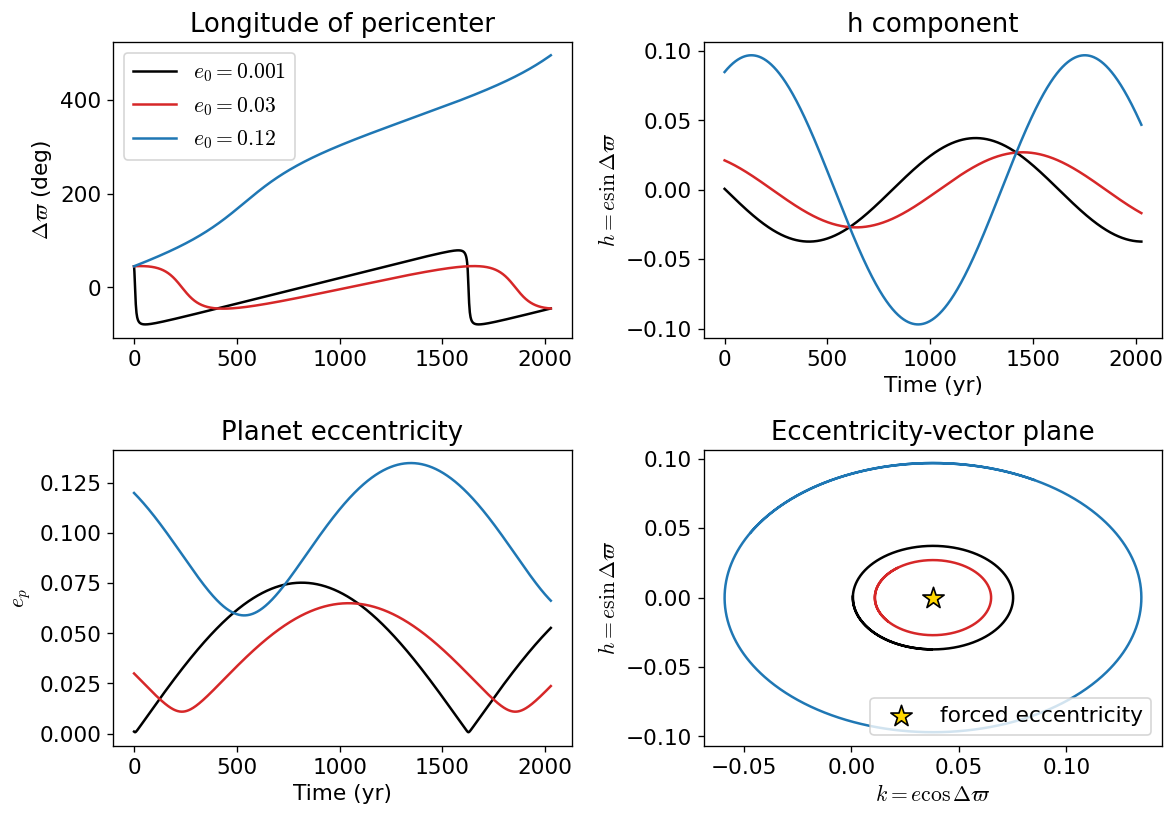

In [ ]:
# Evolve a P-Type example with three initial eccentricities.
t = np.linspace(0, 1.25 * period_MN, 1200)
initial_eccentricities = [0.001, 0.03, 0.12]
delta_varpi0 = np.radians(45)

fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=False)

for e0, color in zip(initial_eccentricities, colors):
    k, h, e, dvarpi, e_free, phase = secular_solution(t, g_MN, eps_MN, e0, delta_varpi0=delta_varpi0)
    axes[0, 0].plot(t, np.degrees(np.unwrap(dvarpi)), color=color, label=rf"$e_0={e0}$")
    axes[1, 0].plot(t, e, color=color)
    axes[0, 1].plot(t, h, color=color)
    axes[1, 1].plot(k, h, color=color)

axes[1, 1].scatter([eps_MN], [0], marker="*", s=180, color="gold", edgecolor="black", zorder=5, label="forced eccentricity")
axes[0, 0].set_ylabel(r"$\Delta\varpi$ (deg)")
axes[1, 0].set_ylabel(r"$e_p$")
axes[0, 1].set_ylabel(r"$h=e\sin\Delta\varpi$")
axes[1, 1].set_ylabel(r"$h=e\sin\Delta\varpi$")
axes[1, 0].set_xlabel("Time (yr)")
axes[0, 1].set_xlabel("Time (yr)")
axes[1, 1].set_xlabel(r"$k=e\cos\Delta\varpi$")
axes[0, 0].legend(loc="best")
axes[1, 1].legend(loc="best")
axes[0, 0].set_title("Longitude of pericenter")
axes[1, 0].set_title("Planet eccentricity")
axes[0, 1].set_title("h component")
axes[1, 1].set_title("Eccentricity-vector plane")

plt.tight_layout()
plt.show()

## Fast and slow circumbinary eccentricity components

The low-order secular forced eccentricity for a P-Type planet can become very small for symmetric binaries. However, circumbinary orbits also have short-period variations caused by the binary's fast orbital motion.

One useful estimate for the fast component is

$$
\epsilon_{\rm ff} =
\frac{3}{4}\mu^\dagger(1-\mu^\dagger)\alpha^{-2}
\sqrt{1+\frac{34}{3}e_{\rm bin}^2}.
$$

A rough time-averaged eccentricity estimate can be written as

$$
\langle e_p\rangle \approx \frac{4}{\pi}\left(\epsilon_{\rm MN}+\epsilon_{\rm ff}\right).
$$

This is not the same as the slow secular forced eccentricity. It is a reminder that a circumbinary planet can show short-period eccentricity variations even when the leading-order secular forced eccentricity is small.


In [14]:
def fast_forced_circumbinary(m_A, m_B, a_bin, a_p, e_bin):
    """Return the fast circumbinary eccentricity estimate."""
    mu_dag = m_B / (m_A + m_B)
    alpha = a_p / a_bin
    eps_ff = 0.75 * mu_dag * (1 - mu_dag) * alpha**(-2) * np.sqrt(1 + (34/3) * e_bin**2)
    return eps_ff

eps_ff = fast_forced_circumbinary(m_A, m_B, a_bin, a_p, e_bin)
e_mean_est = 4/np.pi * (abs(eps_MN) + eps_ff)

print(f"The slow secular forced eccentricity magnitude is |eps_MN| = {abs(eps_MN):.4f}.")
print(f"The fast eccentricity estimate is eps_ff = {eps_ff:.4f}.")
print(f"The rough mean eccentricity estimate is <e_p> = {e_mean_est:.4f}.")

The slow secular forced eccentricity magnitude is |eps_MN| = 0.0380.
The fast eccentricity estimate is eps_ff = 0.0076.
The rough mean eccentricity estimate is <e_p> = 0.0580.


## Benchmarking against an N-body simulation

The secular model is useful because it is cheap and transparent. An N-body model is more complete because it retains short-period terms, resonant effects, and non-linear behavior. A good workflow is:

1. use the secular model to predict $e_{\rm forced}$ and $g$,
2. choose initial conditions with a known $e_{\rm free}$,
3. run the N-body simulation,
4. compare the measured eccentricity oscillation against the secular prediction,
5. investigate any disagreement.

```{admonition} What disagreement means
:class: warning

If the N-body result disagrees with the secular model, first check the assumptions: Is $\alpha$ small enough? Is the planet near a mean motion resonance? Is the eccentricity too large? Is the system near the stability boundary?
```

The optional cell below is written so the notebook still runs if `rebound` is not installed.


In [15]:
try:
    import rebound
    rebound_available = True
except ImportError:
    rebound_available = False

print(f"REBOUND available: {rebound_available}")

if not rebound_available:
    print("Install REBOUND in your environment if you want to run the direct N-body comparison.")
    print("For example, in a notebook cell you can use: %pip install rebound")


REBOUND available: True


The S-Type forced eccentricity used for the initial planet orbit is e_F = 0.0412.
The secular period from the toy model is 36.6 yr.


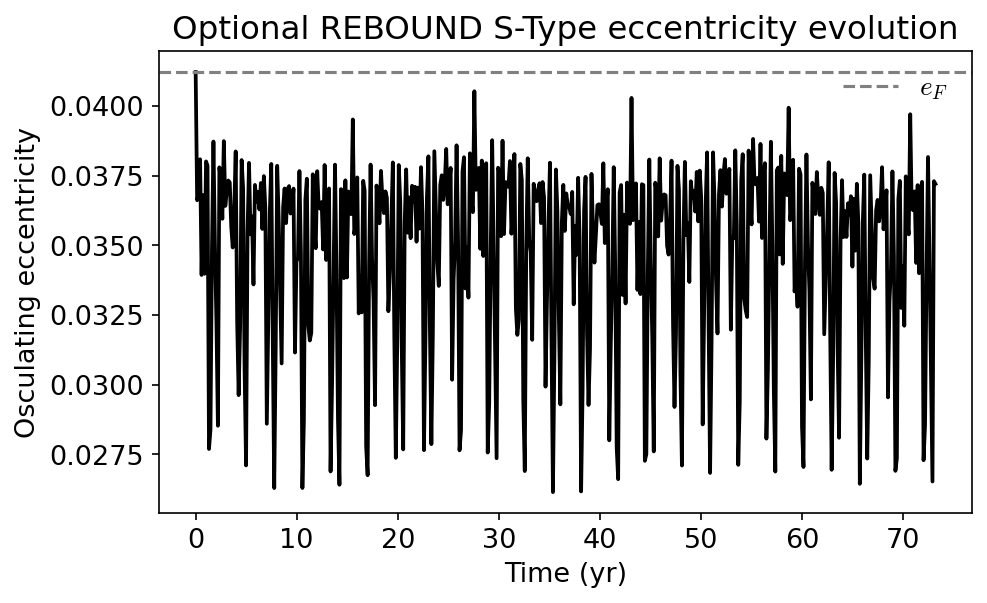

In [16]:
def run_optional_rebound_s_type_example():
    """Run a short S-Type REBOUND simulation if REBOUND is installed.

    This example uses the same S-Type toy model as the Heppenheimer secular example:
    a planet orbits the host star m1, while the stellar companion m3 is the external perturber.

    This is a demonstration cell, not a production-quality stability simulation.
    """
    if not rebound_available:
        return None

    # ------------------------------------------------------------
    # S-Type toy model parameters
    # ------------------------------------------------------------
    m1 = 1.0          # host star mass in solar masses
    m2 = 0.0          # planet treated as a test particle
    m3 = 1.0          # stellar companion mass in solar masses

    a_bin = 1.0       # binary semimajor axis in AU
    e_bin = 0.3       # binary eccentricity

    alpha = 0.1       # S-Type hierarchy parameter: alpha = a_p / a_bin
    a_p = alpha * a_bin

    # The S-Type secular model uses the perturber mass ratio m3/(m1 + m2).
    mu_sec = m3 / (m1 + m2)

    # Planet mean motion around the host star.
    n_p = np.sqrt(4 * np.pi**2 * (m1 + m2) / a_p**3)

    # Heppenheimer forced eccentricity and secular frequency.
    e_forced = 1.25 * alpha * e_bin / (1 - e_bin**2)
    g_sec = 0.75 * mu_sec * alpha**3 * n_p / (1 - e_bin**2)**1.5
    period_sec = 2 * np.pi / g_sec

    # Keplerian periods used only to choose a reasonable timestep.
    period_p = np.sqrt(a_p**3 / (m1 + m2))
    period_bin = np.sqrt(a_bin**3 / (m1 + m3))
    dt = min(period_p / 40, period_bin / 100)

    # ------------------------------------------------------------
    # Build the REBOUND simulation
    # ------------------------------------------------------------
    sim = rebound.Simulation()
    sim.units = ("yr", "AU", "Msun")
    sim.integrator = "whfast"
    sim.dt = dt

    # Add the host star.
    sim.add(m=m1)

    # Add the S-Type planet around the host star.
    # Starting the planet near the forced eccentricity reduces the free eccentricity.
    sim.add(m=m2, a=a_p, e=e_forced, omega=0.0, f=0.0, primary=sim.particles[0])

    # Add the stellar companion as the outer perturber.
    # Because the planet is massless, using the host star as the primary is equivalent
    # to using the center of mass of the inner pair for this toy setup.
    sim.add(m=m3, a=a_bin, e=e_bin, omega=0.0, f=0.0, primary=sim.particles[0])

    sim.move_to_com()

    # ------------------------------------------------------------
    # Integrate and record osculating eccentricity
    # ------------------------------------------------------------
    times = np.linspace(0, 2 * period_sec, 500)
    ecc = np.zeros_like(times)

    for i, time in enumerate(times):
        sim.integrate(time)
        orbit = sim.particles[1].orbit(primary=sim.particles[0])
        ecc[i] = orbit.e

    return times, ecc, e_forced, period_sec


result = run_optional_rebound_s_type_example()

if result is not None:
    times, ecc, e_forced, period_sec = result

    fig, ax = plt.subplots(figsize=(7, 4), dpi=150)
    ax.plot(times, ecc, color="black", linewidth=1.8)
    ax.axhline(e_forced, color="0.5", linestyle="--", linewidth=1.5, label=r"$e_F$")

    ax.set_xlabel("Time (yr)")
    ax.set_ylabel("Osculating eccentricity")
    ax.set_title("Optional REBOUND S-Type eccentricity evolution")
    ax.legend(frameon=False)

    print(f"The S-Type forced eccentricity used for the initial planet orbit is e_F = {e_forced:.4f}.")
    print(f"The secular period from the toy model is {period_sec:.1f} yr.")

    plt.show()

## Common mistakes

### Treating circular as dynamically cold

A circular initial orbit has $e_p=0$, but that does not mean $e_{\rm free}=0$. If the forced eccentricity is nonzero, a circular orbit begins displaced from the forced point.

### Forgetting the pericenter alignment

The initial eccentricity alone is not enough. The free eccentricity depends on the vector difference between the initial eccentricity vector and the forced eccentricity vector.

### Confusing S-Type and P-Type semimajor axis ratios

For S-Type problems, $\alpha=a_p/a_{\rm bin}$ is small. For P-Type problems, $\alpha=a_p/a_{\rm bin}$ is large, and the expansion uses inverse powers of $\alpha$.

### Using a secular model near a mean motion resonance

Secular theory averages over the orbital periods. A mean motion resonance is specifically about a commensurability between orbital periods. That is exactly where simple averaging can fail.

### Assuming the first-order model is always enough

The first-order model is valuable because it is transparent. It is not universally accurate. Second-order terms, short-period variations, and direct N-body integrations become necessary as the perturbation strengthens.

### Forgetting the sign of the forced eccentricity

In some P-Type expressions, the forced eccentricity can be signed. A negative value means the forced vector points anti-aligned with the binary pericenter in the chosen coordinate convention.


## Copy-paste reference

This section collects the main reusable functions from the guide.


In [17]:
def s_type_forced_free_summary(m_host, m_planet, m_companion, a_p, a_bin, e_bin, e0, delta_varpi0, model="heppenheimer"):
    """Return a dictionary summarizing an S-Type secular model."""
    if model == "heppenheimer":
        g, e_forced = heppenheimer_s_type(m_host, m_planet, m_companion, a_p, a_bin, e_bin)
    elif model == "marchal":
        g, e_forced, _ = marchal_s_type(m_host, m_planet, m_companion, a_p, a_bin, e_bin)
    else:
        raise ValueError("model must be 'heppenheimer' or 'marchal'")

    e_free = free_eccentricity(e0, delta_varpi0, e_forced)
    return {
        "g": g,
        "secular_period": 2 * np.pi / g,
        "e_forced": e_forced,
        "e_free": e_free,
        "e_min": abs(e_forced - e_free),
        "e_max": e_forced + e_free,
    }

summary = s_type_forced_free_summary(m_host, m_planet, m_companion, a_p, a_bin, e_bin, e0=0.0, delta_varpi0=0.0)

for key, value in summary.items():
    print(f"{key}: {value:.5f}")


g: 60.69236
secular_period: 0.10353
e_forced: 2.06044
e_free: 2.06044
e_min: 0.00000
e_max: 4.12088


## References and source notes

This guide is based on the standard secular eccentricity-vector picture used in studies of planets in binary-star systems. The most important source ideas are:

- Heppenheimer's first-order S-Type secular model.
- Marchal-style corrected S-Type secular frequencies and forced eccentricities.
- Andrade-Ines et al.'s discussion of applicability domains for first- and second-order secular theories.
- Moriwaki and Nakagawa's circumbinary forced-eccentricity model.
- Numerical comparisons showing where secular models match or fail against N-body integrations.

Useful references:

- Andrade-Ines, E., Beaugé, C., Michtchenko, T., & Robutel, P. 2016, *Celestial Mechanics and Dynamical Astronomy*, 124, 405.
- Heppenheimer, T. A. 1978, *Astronomy & Astrophysics*, 65, 421.
- Marchal, C. 1990, *The Three-Body Problem*.
- Moriwaki, K., & Nakagawa, Y. 2004, *The Astrophysical Journal*, 609, 1065.
- Quarles, B., Lissauer, J. J., & Kaib, N. 2018, *The Astronomical Journal*, 155, 64.
- Quarles, B., Bhaskar, H. G., & Li, G. 2024, *Main-sequence systems: orbital stability in stellar binaries*.
